安裝套件

In [7]:
import pandas as pd       # 用來讀取和處理資料
import numpy as np        # 處理數值運算
import matplotlib.pyplot as plt  # 畫圖
import seaborn as sns     # 更漂亮的統計圖表
import folium             # 做互動式地圖

讀取csv檔

In [2]:
# 指定檔案相對路徑
file_path = './accident_113_taipei.csv'

# 讀取資料
df = pd.read_csv(file_path, encoding='big5')

# 確認前幾筆資料與欄位名稱
print("✅ 讀取成功！")
print("共有", df.shape[0], "筆資料與", df.shape[1], "個欄位\n")
print("欄位名稱：", list(df.columns), "\n")

✅ 讀取成功！
共有 51810 筆資料與 50 個欄位

欄位名稱： ['發生年度', '發生月', '發生日', '發生時-Hours', '發生分', '處理別-編號', '區序', '肇事地點', '死亡人數', '2-30日死亡人數', '受傷人數', '當事人序號', '車種', '天候', '道路照明設備', '道路類別', '速限-速度限制', '道路型態', '事故位置', '路面狀況1', '路面狀況2', '路面狀況3', '道路障礙1', '道路障礙2', '號誌1', '號誌2', '車道劃分-分向', '車道劃分-分道1', '車道劃分-分道2', '車道劃分-分道3', '事故類型及型態', '性別', '年齡', '受傷程度', '主要傷處', '保護裝置', '行動電話', '車輛用途', '當事者行動狀態', '駕駛資格情形', '駕駛執照種類', '飲酒情形', '車輛撞擊部位1', '車輛撞擊部位2', '肇因碼-個別', '肇因碼-主要', '個人肇逃否', '職業', '座標-X', '座標-Y'] 



避免「同時間、地點的事故被重複計算」

In [3]:
grouped_df = (
    df.groupby(['發生月', '發生日', '發生時-Hours', '發生分', '肇事地點'])
      .agg({
          '死亡人數': 'sum',
          '受傷人數': 'sum',
          '事故類型及型態': 'first',
          '區序': 'first',
          '天候': 'first',
          '道路型態': 'first',
          '座標-X': 'first',
          '座標-Y': 'first',
      })
    .reset_index()
)
grouped_df['傷亡人數'] = grouped_df['死亡人數'] + grouped_df['受傷人數']
grouped_df.info()

# 另存為 Excel
grouped_df.to_excel('accident_113_grouped.xlsx', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22357 entries, 0 to 22356
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   發生月        22357 non-null  int64  
 1   發生日        22357 non-null  int64  
 2   發生時-Hours  22357 non-null  int64  
 3   發生分        22357 non-null  int64  
 4   肇事地點       22357 non-null  object 
 5   死亡人數       22357 non-null  float64
 6   受傷人數       22357 non-null  float64
 7   事故類型及型態    22354 non-null  float64
 8   區序         22357 non-null  object 
 9   天候         22357 non-null  int64  
 10  道路型態       22354 non-null  float64
 11  座標-X       22357 non-null  float64
 12  座標-Y       22357 non-null  float64
 13  傷亡人數       22357 non-null  float64
dtypes: float64(7), int64(5), object(2)
memory usage: 2.4+ MB


各區域車禍事故數量

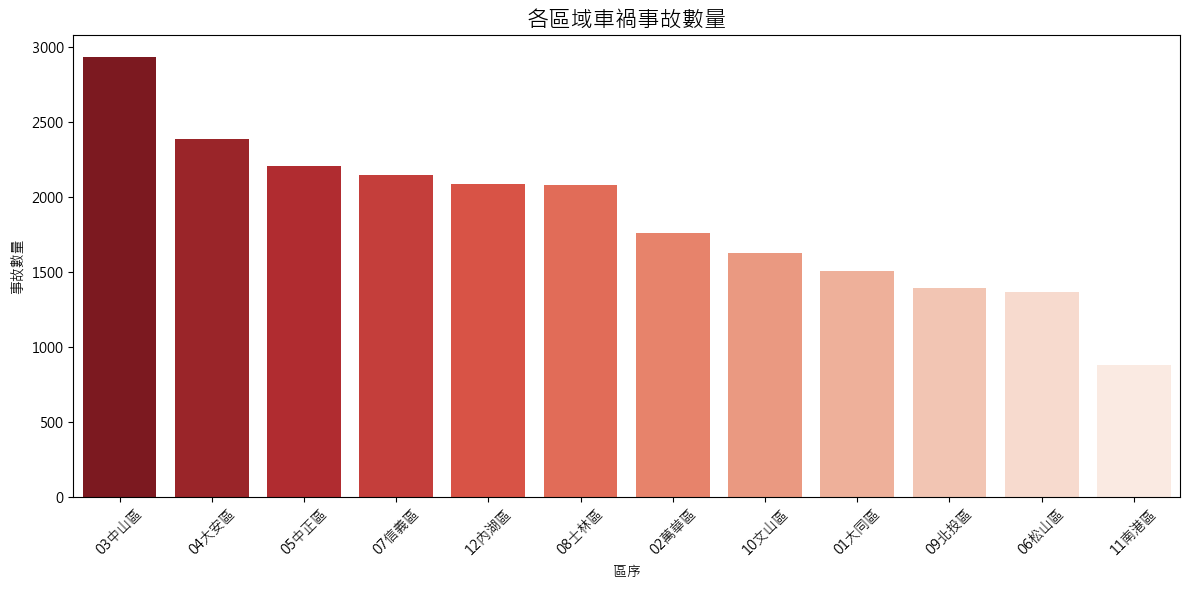

In [10]:
# 以區序分組，統計資料筆數（即事故數量）
area_counts = grouped_df['區序'].value_counts()

# reset_index() -> DataFrame
area_counts = area_counts.reset_index()

# 改欄位名稱
area_counts.columns = ['區序', '事故數量']

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False # 顯示負號
plt.figure(figsize=(12, 6))
sns.barplot(
    x='區序',
    y='事故數量',
    data=area_counts,
    hue='區序',  
    dodge=False,  
    palette='Reds_r',
    legend=False  
)
plt.title('各區域車禍事故數量', fontsize=16)
plt.xlabel('區序')
plt.ylabel('事故數量')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

各時段車禍分布
主要目的：觀察每日不同時段的車禍發生趨勢

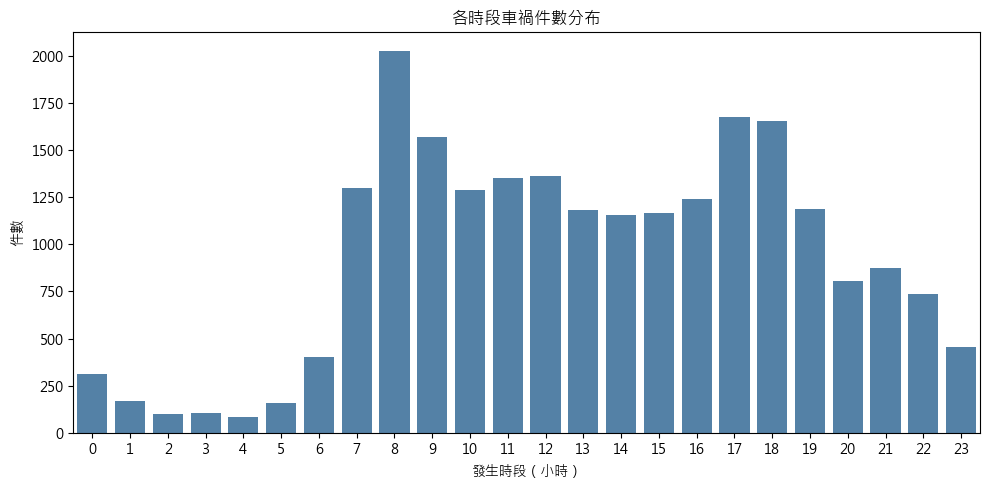

In [13]:
hour_counts = grouped_df.groupby("發生時-Hours").size().reset_index(name="件數")

plt.figure(figsize=(10, 5))
sns.barplot(x="發生時-Hours", y="件數", data=hour_counts, color="steelblue")
plt.title("各時段車禍件數分布")
plt.xlabel("發生時段（小時）")
plt.ylabel("件數")
plt.tight_layout()
plt.show()

前10大事故類型
主要目的：分析最常發生的事故型態

C:\Users\dcfoa\AppData\Local\Temp\ipykernel_21388\1718491899.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="事故原因", x="件數", data=type_counts, palette="Reds_r")


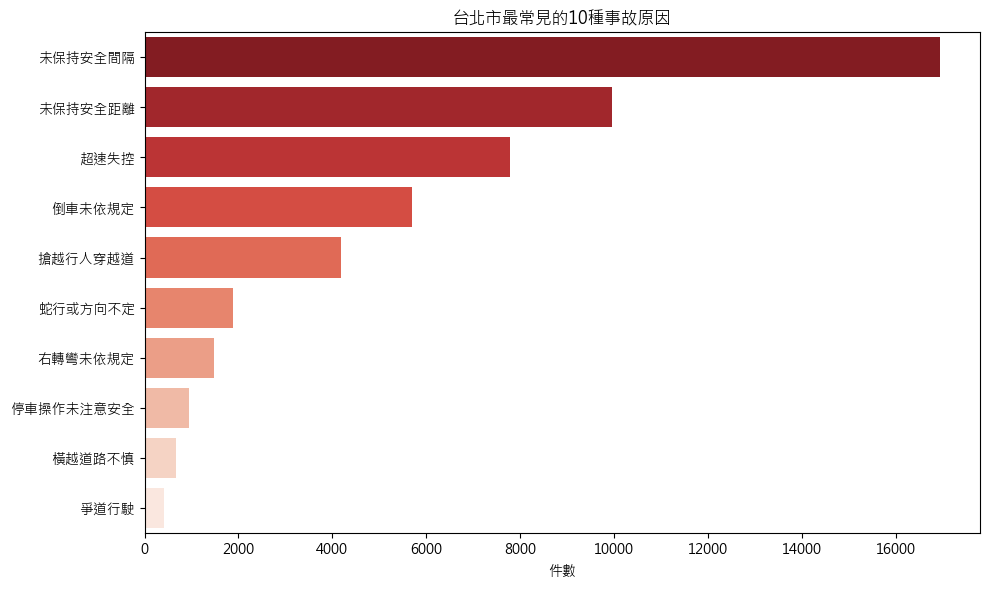

In [15]:
cause_map = {
    1: "違規超車", 2: "爭道行駛", 3: "蛇行或方向不定", 4: "逆向行駛", 5: "未靠右行駛",
    6: "未依規定讓車", 7: "變換車道或方向不當", 8: "左轉彎未依規定", 9: "右轉彎未依規定",
    10: "迴轉未依規定", 11: "橫越道路不慎", 12: "倒車未依規定", 13: "超速失控",
    14: "未依規定減速", 15: "搶越行人穿越道", 16: "未保持安全距離", 17: "未保持安全間隔",
    18: "停車操作未注意安全", 19: "起步未注意安全", 20: "吸食違禁物駕駛失控", 21: "酒醉駕駛失控",
    22: "疲勞駕駛失控", 23: "未注意車前狀態", 24: "搶(闖)越平交道", 25: "違反號誌管制或指揮",
    26: "違反標誌(線)禁制", 27: "未依規定使用燈光", 28: "暗處停車無燈光", 29: "夜間行駛無燈光設備",
    30: "裝載貨物不穩妥", 31: "載貨超重失控", 32: "超載人員失控", 33: "貨物超長寬高肇事",
    34: "裝卸貨物不當", 35: "裝載未盡安全措施", 36: "未待乘客安全上下開車", 37: "其他裝載不當肇事",
    38: "違規停車或暫停不當", 39: "拋錨未採安全措施", 40: "開啟車門不當肇事", 41: "使用手機失控",
    42: "其他違規或不當行為", 43: "不明原因肇事", 44: "尚未發現肇事因素", 45: "煞車失靈",
    46: "方向系統故障", 47: "燈光系統故障", 48: "輪胎爆裂", 49: "零件脫落",
    50: "其他機件故障", 51: "行人未依規穿越道路", 52: "行人違反號誌或手勢",
    53: "行人未注意左右來車", 54: "在道路上嬉戲奔走", 55: "未待車輛停妥上下車",
    56: "上下車未注意安全", 57: "頭手伸出車外肇事", 58: "乘坐不當跌落", 59: "道路施工未設標識",
    60: "其他行人或乘客疏失", 61: "無安全警告設施", 62: "交通設施失靈或損毀",
    63: "交通指揮不當", 64: "平交道未放柵欄", 65: "其他交通管制不當", 66: "動物竄出", 67: "尚未發現肇事因素"
}

df["事故原因"] = df["事故類型及型態"].map(cause_map)

type_counts = df["事故原因"].value_counts().head(10).reset_index()
type_counts.columns = ["事故原因", "件數"]

plt.figure(figsize=(10, 6))
sns.barplot(y="事故原因", x="件數", data=type_counts, palette="Reds_r")
plt.title("台北市最常見的10種事故原因")
plt.xlabel("件數")
plt.ylabel("")
plt.tight_layout()
plt.show()


繪製事故發生地點，及相關資訊

In [ ]:
import folium
from folium.plugins import MarkerCluster
import geopandas as gpd
import pandas as pd

# 讀取台北市行政區 GeoJSON
taipei_map = gpd.read_file('./geojson_Taipei.json')
if taipei_map.crs is None or taipei_map.crs.to_epsg() != 4326:
    taipei_map = taipei_map.to_crs(epsg=4326)

# 只取有經緯度的資料
df_map = grouped_df.dropna(subset=['座標-X', '座標-Y']).copy()

# 依地點分群（同地點可能多次事故）
df_map['X_round'] = df_map['座標-X'].round(3)
df_map['Y_round'] = df_map['座標-Y'].round(3)
df_map.to_excel('accident_map_data.xlsx', index=False)

df_grouped_location = (
    df_map.groupby(['區序', 'X_round', 'Y_round'], as_index=False)
    .agg({
        '死亡人數': 'sum',
        '受傷人數': 'sum',
        '傷亡人數': 'sum',
        # 最常出現地點名稱
        '肇事地點': lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
    })
)
df_grouped_location['發生次數'] = df_map.groupby(
    ['區序', 'X_round', 'Y_round']
).size().values

# 建立 folium 地圖
center = [25.0330, 121.5654]
m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")

# 台北市行政區邊界
folium.GeoJson(
    taipei_map.__geo_interface__,
    name="行政區邊界",
    style_function=lambda x: {
        "fillColor": "transparent",
        "color": "#2c3e50",
        "weight": 2,
        "fillOpacity": 0
    }
).add_to(m)

# 定義每個區的顏色（12個行政區）
district_colors = {
    '01大同區': '#e74c3c',  # 紅
    '02萬華區': '#3498db',  # 藍
    '03中山區': '#2ecc71',  # 綠
    '04大安區': '#f39c12',  # 橙
    '05中正區': '#9b59b6',  # 紫
    '06松山區': '#1abc9c',  # 青綠
    '07信義區': '#e67e22',  # 深橙
    '08士林區': '#34495e',  # 深灰
    '09北投區': '#16a085',  # 深青
    '10文山區': '#c0392b',  # 深紅
    '11南港區': '#8e44ad',  # 深紫
    '12內湖區': '#27ae60',  # 深綠
}

# 為每個行政區建立獨立的圖層群組
district_groups = {}
for district, _ in district_colors.items():
    # 處理可能的區序格式（例如 "03中山區" 或 "中山區"）
    district_name = district
    color = district_colors.get(district, '#95a5a6')  # 預設灰色

    # 建立該區的圖層群組
    district_groups[district] = folium.FeatureGroup(
        name=f'{district} (傷亡標記)',
        show=True
    )
# print(df_grouped_location[df_grouped_location['發生次數']>5])
# print('-------------------')

# 將事故點加入對應的區域圖層
for idx, row in df_grouped_location.iterrows():
    district = row['區序']
    color = district_colors.get(district, '#95a5a6')

    casualty = row['傷亡人數']
    radius = 3 if casualty == 0 else 5 if casualty <= 2 else 7 if casualty <= 5 else 10
    fill_opacity = 0.3 if casualty == 0 else 0.5 if casualty <= 2 else 0.6 if casualty <= 5 else 0.8

    popup_text = f"""
    <div style="font-family: Arial; font-size: 12px; width: 200px;">
        <b style="color: {color}; font-size: 14px;">{district}</b><br>
        <hr style="margin: 5px 0;">
        <b>地點：</b>{row['肇事地點']}<br>         <b>發生次數：</b>{int(row['發生次數'])} 次<br>         <b>死亡人數：</b><span style="color: #c0392b;">{int(row['死亡人數'])}</span> 人<br>
        <b>受傷人數：</b><span styl e="color: #e67e22;">{int(row['受傷人數'])}</span> 人<br>
        <b>總傷亡：</b><span style="color: #e74c3c; font-weight: bold;">{int(row[ '傷亡人數'])}</span> 人
    </div>
 """

    folium.CircleMarker(
        location=[row['Y_round'], row['X_round']],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=fill_opacity,
        weight=2,
        popup=folium.Popup(popup_text, max_width=250)
    ).add_to(district_groups[district])

# 將所有區域圖層加到地圖
for district, group in district_groups.items():
    group.add_to(m)

# 統計各區傷亡總數並顯示
district_stats = df_grouped_location.groupby('區序').agg({
    '傷亡人數': 'sum',
    '死亡人數': 'sum',
    '受傷人數': 'sum',
    '發生次數': 'sum'
}).rename(columns={'發生次數': '事故件數'}).sort_values('傷亡人數', ascending=False)

print("各行政區傷亡統計（依總傷亡數排序）：")
print(district_stats)

# 建立圖例
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; left: 50px; width: 280px; 
            background-color: white; border:2px solid #2c3e50;
            border-radius: 5px; z-index:9999;
            padding: 10px; box-shadow: 3px 3px 10px rgba(0,0,0,0.3);">
    <h4 style="margin: 0 0 10px 0; color: #2c3e50;">圖例說明</h4>
    <p style="margin: 5px 0; font-size: 11px;">
        <b>圓圈大小：</b>傷亡人數越多越大<br>
        <b>顏色：</b>不同行政區<br>
        <b>操作：</b>右上角可開關各區圖層
    </p>
'''

# 加入各區顏色說明
for district, color in district_colors.items():
    legend_html += f'''
    <div style="margin: 3px 0;">
        <span style="background-color: {color}; width: 15px; height: 15px; 
                     display: inline-block; border-radius: 50%; margin-right: 5px;"></span>
        <span style="font-size: 11px;">{district}</span>
    </div>
    '''

legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

# 圖層控制
folium.LayerControl(collapsed=False).add_to(m)

# 顯示和儲存
m
m.save("taipei_district_summary.html")

with open("taipei_district_summary.html", "r", encoding="utf-8") as f:
    html = f.read()

if "<meta charset=" not in html:
    html = html.replace("<head>", "<head>\n<meta charset='utf-8'>\n")

with open("Taipei_district_analyze.html", "w", encoding="utf-8") as f:
    f.write(html)

各行政區傷亡統計（依總傷亡數排序）：
         傷亡人數  死亡人數    受傷人數  事故件數
區序                               
03中山區  9735.0   8.0  9727.0  2931
04大安區  7620.0   7.0  7613.0  2383
05中正區  7294.0  36.0  7258.0  2207
08士林區  7245.0  19.0  7226.0  2078
12內湖區  6546.0  34.0  6512.0  2087
07信義區  6509.0   3.0  6506.0  2147
02萬華區  6163.0  38.0  6125.0  1760
10文山區  5906.0  12.0  5894.0  1623
01大同區  5420.0  17.0  5403.0  1506
09北投區  4837.0  10.0  4827.0  1392
06松山區  4436.0  28.0  4408.0  1366
11南港區  2812.0   3.0  2809.0   877


In [ ]:
# import folium
# from folium.plugins import HeatMap
# import geopandas as gpd

# # 1) 台北市行政區 (GeoJSON) 讀進來（WGS84）
# taipei_map = gpd.read_file('./geojson_Taipei.json')
# if taipei_map.crs is None or taipei_map.crs.to_epsg() != 4326:
#     taipei_map = taipei_map.to_crs(epsg=4326)

# # 2) 只取有經緯度的資料
# df_map = grouped_df.dropna(subset=['座標-X', '座標-Y']).copy()

# # 3) 只保留在台北市邊界內的點（避免資料跑出邊界）
# gdf_pts = gpd.GeoDataFrame(
#     df_map, geometry=gpd.points_from_xy(df_map['座標-X'], df_map['座標-Y']), crs="EPSG:4326"
# )
# gdf_pts = gpd.sjoin(
#     gdf_pts, taipei_map[['geometry']], how='inner', predicate='within')

# # 4) 建立 folium 地圖（置中台北）
# center = [25.0330, 121.5654]
# m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")

# # 5) 疊上台北市行政區邊界（半透明）
# folium.GeoJson(
#     taipei_map.__geo_interface__,
#     name="Taipei Boundary",
#     style_function=lambda x: {"fillColor": "#6baed6",
#                               "color": "#3182bd", "weight": 1, "fillOpacity": 0.2}
# ).add_to(m)

# # 6) 加權熱力圖：用死亡+受傷人數做權重
# heat_data = [
#     [row['座標-Y'], row['座標-X'], row['死亡人數'] + row['受傷人數']]
#     for idx, row in gdf_pts.iterrows()
# ]

# HeatMap(
#     heat_data,
#     radius=15,
#     blur=18,
#     max_zoom=13,
#     min_opacity=0.3,
# ).add_to(m)

# # 7) 加上互動小點 (CircleMarker) 顯示事故詳細資訊
# # 新增圖層群組
# # marker_layer = folium.FeatureGroup(name="事故標記").add_to(m)

# # for idx, row in gdf_pts.iterrows():
# #     popup_text = (
# #         f"發生日期: {int(row['發生月'])}/{int(row['發生日'])} "
# #         f"{int(row['發生時-Hours']):02d}:{int(row['發生分']):02d}<br>"
# #         f"死亡人數: {int(row['死亡人數'])}<br>"
# #         f"受傷人數: {int(row['受傷人數'])}<br>"
# #         f"事故類型: {row['事故類型及型態']}"
# #     )
    
# #     folium.CircleMarker(
# #         location=[row['座標-Y'], row['座標-X']],
# #         radius=4,
# #         color='blue',
# #         fill=True,
# #         fill_color='blue',
# #         fill_opacity=0.7,
# #         popup=folium.Popup(popup_text, max_width=300)
# #     ).add_to(marker_layer)

# # 8) 加上圖層控制
# folium.LayerControl().add_to(m)

# # 9) 顯示地圖
# m  # 在 Notebook 會直接顯示

# # 10) 如果需要存檔
# m.save("accident_interactive_hotspots.html")